# Chapter 17 · Notebook 2: experiments tracked in MLflow

In the video every experiment is logged to an **MLflow server on an EC2 instance** with an **S3 bucket** for artifacts.
Here a local `mlflow server` stands in for it. The code is identical except for the tracking URI.

| Round | Question | Model | Winner in the video |
|---|---|---|---|
| 1 | baseline: how good is a simple model? | Random Forest + bag of words | – |
| 2 | bag of words or TF-IDF? unigrams, bigrams or trigrams? | RF | TF-IDF (1,3) |
| 3 | how many features? (1000 → 10000) | RF | 1000 |
| 4 | how should we handle class imbalance? | RF | SMOTE oversampling |
| 5 | which algorithm, with Optuna tuning? | LR, SVM, NB, KNN, XGB, LightGBM, RF | LightGBM |
| 6 | does stacking beat LightGBM? | LR + KNN + LightGBM | no, keep LightGBM |

**What we compare:** accuracy, plus per-class precision and recall. The main criterion is **recall on the negative class**,
because negative comments are the minority class and the one a creator most wants to catch.

Two deliberate differences from the video (both explained in the notes):
* the vectorizer and resampling are fitted on the **training split only**. The course's baseline notebook fits the vectorizer on all rows, and its LightGBM-tuning notebook applies SMOTE before splitting; both leak test information.
* Optuna tunes on a **validation split** carved out of the training data, not on the test set (the course scores trials on the test set).

In [1]:
import os, sys, time, shutil, subprocess, urllib.request
PROJECT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
BIN = os.path.dirname(sys.executable)
MLFLOW_PORT = 5050
TRACKING_URI = f"http://127.0.0.1:{MLFLOW_PORT}"
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

def server_up():
    try:
        with urllib.request.urlopen(TRACKING_URI + "/health", timeout=1) as r:
            return r.status == 200
    except Exception:
        return False

def start_mlflow_server(fresh=False):
    """Local stand-in for `mlflow server` on EC2: SQLite for runs, a folder for artifacts (S3 in the video)."""
    if fresh:
        stop_mlflow_server()
        for p in ("mlflow.db",):
            if os.path.exists(os.path.join(PROJECT, p)): os.remove(os.path.join(PROJECT, p))
        shutil.rmtree(os.path.join(PROJECT, "mlartifacts"), ignore_errors=True)
    if server_up():
        print("MLflow server already running at", TRACKING_URI); return
    log = open(os.path.join(PROJECT, "logs_mlflow_server.txt"), "w")
    subprocess.Popen([os.path.join(BIN, "mlflow"), "server",
                      "--backend-store-uri", "sqlite:///mlflow.db",
                      "--artifacts-destination", "./mlartifacts",
                      "--host", "127.0.0.1", "--port", str(MLFLOW_PORT)],
                     cwd=PROJECT, stdout=log, stderr=subprocess.STDOUT, start_new_session=True)
    for _ in range(120):
        if server_up():
            print("MLflow server started at", TRACKING_URI); return
        time.sleep(0.5)
    raise RuntimeError("MLflow server did not start; see logs_mlflow_server.txt")

def stop_mlflow_server():
    subprocess.run(["pkill", "-f", f"mlflow server.*port {MLFLOW_PORT}"])
    subprocess.run(["pkill", "-f", "mlflow.server.jobs._huey_consumer"])
    time.sleep(1)

start_mlflow_server(fresh=True)     # notebook 2 is the first to write to the server: start clean

MLflow server started at http://127.0.0.1:5050


In [2]:
import json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import optuna
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri(TRACKING_URI)
os.makedirs("cm", exist_ok=True)

df = pd.read_csv("reddit_preprocessing.csv").dropna()
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df["clean_comment"], df["category"], test_size=0.2, stratify=df["category"], random_state=42)
print("train", X_train_txt.shape, " test", X_test_txt.shape)
RESULTS = []          # one row per run → summary charts + reports/experiment_summary.json

train (29329,)  test (7333,)


In [3]:
LABELS = {-1: "negative", 0: "neutral", 1: "positive"}

def log_and_score(experiment, run_name, model, X_tr, y_tr, X_te, params, tags=None, fit=True):
    # fit → predict → log params, metrics and a confusion-matrix image to MLflow
    mlflow.set_experiment(experiment)
    with mlflow.start_run(run_name=run_name):
        t0 = time.time()
        if fit:
            model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        if pred.ndim > 1: pred = pred.ravel()
        rep = classification_report(y_test, pred, output_dict=True, zero_division=0)
        metrics = {"accuracy": accuracy_score(y_test, pred), "macro_f1": rep["macro avg"]["f1-score"],
                   "fit_seconds": time.time() - t0}
        for k, name in LABELS.items():
            metrics[f"{name}_precision"] = rep[str(k)]["precision"]
            metrics[f"{name}_recall"] = rep[str(k)]["recall"]
            metrics[f"{name}_f1"] = rep[str(k)]["f1-score"]
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.set_tags({"experiment_round": experiment, **(tags or {})})

        fig, ax = plt.subplots(figsize=(4, 3.4))
        sns.heatmap(confusion_matrix(y_test, pred, labels=[-1, 0, 1]), annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=list(LABELS.values()), yticklabels=list(LABELS.values()), ax=ax)
        ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(run_name, fontsize=9)
        path = f"cm/{experiment}__{run_name}.png"
        plt.tight_layout(); fig.savefig(path, dpi=90); plt.close(fig)
        mlflow.log_artifact(path)
    row = {"experiment": experiment, "run": run_name, **{k: round(v, 4) for k, v in metrics.items()}}
    RESULTS.append(row)
    print(f"{run_name:<32} acc={metrics['accuracy']:.3f}  neg_recall={metrics['negative_recall']:.3f}  "
          f"macro_f1={metrics['macro_f1']:.3f}  ({metrics['fit_seconds']:.0f}s)")
    return row

def rf():
    return RandomForestClassifier(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)

def table(experiment):
    cols = ["run", "accuracy", "negative_recall", "negative_precision", "neutral_recall", "positive_recall", "macro_f1"]
    return pd.DataFrame([r for r in RESULTS if r["experiment"] == experiment])[cols].set_index("run")

## Round 1 · Baseline  (video: "Exp 1 – baseline model")
Bag of words (`CountVectorizer`, 10,000 features) + Random Forest (200 trees, depth 15).

In [4]:
vec = CountVectorizer(max_features=10000)
Xtr, Xte = vec.fit_transform(X_train_txt), vec.transform(X_test_txt)
log_and_score("exp1-baseline", "rf-bow-10k", rf(), Xtr, y_train, Xte,
              {"vectorizer": "bow", "max_features": 10000, "ngram_range": "(1,1)", "n_estimators": 200, "max_depth": 15})
table("exp1-baseline")

2026/09/17 00:42:37 INFO mlflow.tracking.fluent: Experiment with name 'exp1-baseline' does not exist. Creating a new experiment.


🏃 View run rf-bow-10k at: http://127.0.0.1:5050/#/experiments/1/runs/93a8194b30d44cbf917035f3365a3e2f
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/1
rf-bow-10k                       acc=0.643  neg_recall=0.004  macro_f1=0.486  (0s)


,accuracy,negative_recall,negative_precision,neutral_recall,positive_recall,macro_f1
run,,,,,,
rf-bow-10k,0.6431,0.0042,1.0,0.7991,0.8523,0.4864


**≈64% accuracy, the same as in the video**. But look at negative recall: almost **zero**.
A depth-15 forest on 10,000 sparse count features almost never predicts the minority class. Its negative *precision* looks perfect only because it makes so few negative predictions.
That's exactly why the instructor says "don't rely on precision, look at recall".

## Round 2 · Bag of words vs TF-IDF × n-gram range  (6 runs, 5000 features)
* **Bag of words**: raw counts of each word or n-gram.
* **TF-IDF**: counts down-weighted for terms that appear in many comments, so rare but informative terms stand out.

In [5]:
for vec_name, Vec in [("bow", CountVectorizer), ("tfidf", TfidfVectorizer)]:
    for ngram in [(1, 1), (1, 2), (1, 3)]:
        vec = Vec(ngram_range=ngram, max_features=5000)
        Xtr, Xte = vec.fit_transform(X_train_txt), vec.transform(X_test_txt)
        log_and_score("exp2-bow-vs-tfidf", f"{vec_name}-{ngram}", rf(), Xtr, y_train, Xte,
                      {"vectorizer": vec_name, "ngram_range": str(ngram), "max_features": 5000})
table("exp2-bow-vs-tfidf")

2026/09/17 00:42:38 INFO mlflow.tracking.fluent: Experiment with name 'exp2-bow-vs-tfidf' does not exist. Creating a new experiment.


🏃 View run bow-(1, 1) at: http://127.0.0.1:5050/#/experiments/2/runs/77d0b55d1e07407998c7d0d900e9b92b
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/2
bow-(1, 1)                       acc=0.648  neg_recall=0.021  macro_f1=0.499  (0s)


🏃 View run bow-(1, 2) at: http://127.0.0.1:5050/#/experiments/2/runs/c3ae1f7182f24251a4b241e9210b3355
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/2
bow-(1, 2)                       acc=0.651  neg_recall=0.024  macro_f1=0.503  (0s)


🏃 View run bow-(1, 3) at: http://127.0.0.1:5050/#/experiments/2/runs/e4621ae8d39e4cd9939c8fba528e650b
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/2
bow-(1, 3)                       acc=0.654  neg_recall=0.045  macro_f1=0.516  (0s)


🏃 View run tfidf-(1, 1) at: http://127.0.0.1:5050/#/experiments/2/runs/8a16e186187040a1a495d67d54196c7f
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/2
tfidf-(1, 1)                     acc=0.650  neg_recall=0.022  macro_f1=0.501  (0s)


🏃 View run tfidf-(1, 2) at: http://127.0.0.1:5050/#/experiments/2/runs/25c5c39cefe649048222a09bf06a623a
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/2
tfidf-(1, 2)                     acc=0.654  neg_recall=0.030  macro_f1=0.508  (0s)


🏃 View run tfidf-(1, 3) at: http://127.0.0.1:5050/#/experiments/2/runs/84fd9e7d2d6f4c3da4f3d35dc623817a
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/2
tfidf-(1, 3)                     acc=0.654  neg_recall=0.049  macro_f1=0.518  (0s)


,accuracy,negative_recall,negative_precision,neutral_recall,positive_recall,macro_f1
run,,,,,,
"bow-(1, 1)",0.6484,0.0212,0.9722,0.8406,0.8224,0.4995
"bow-(1, 2)",0.6512,0.0242,0.9756,0.8406,0.8272,0.5031
"bow-(1, 3)",0.6542,0.0455,0.9146,0.8335,0.8288,0.5165
"tfidf-(1, 1)",0.6499,0.0224,0.9487,0.8399,0.8259,0.5012
"tfidf-(1, 2)",0.6539,0.0303,0.9804,0.8395,0.8313,0.5082
"tfidf-(1, 3)",0.6543,0.0491,0.9205,0.8319,0.8285,0.5183


## Round 3 · TF-IDF (1,3): how many features?  (10 runs: 1000, 2000, …, 10000)

In [6]:
for mf in range(1000, 10001, 1000):
    vec = TfidfVectorizer(ngram_range=(1, 3), max_features=mf)
    Xtr, Xte = vec.fit_transform(X_train_txt), vec.transform(X_test_txt)
    log_and_score("exp3-tfidf-max-features", f"tfidf-trigram-{mf}", rf(), Xtr, y_train, Xte,
                  {"vectorizer": "tfidf", "ngram_range": "(1,3)", "max_features": mf})
t3 = table("exp3-tfidf-max-features"); t3

2026/09/17 00:42:50 INFO mlflow.tracking.fluent: Experiment with name 'exp3-tfidf-max-features' does not exist. Creating a new experiment.


🏃 View run tfidf-trigram-1000 at: http://127.0.0.1:5050/#/experiments/3/runs/dc37f863d6e54baeb6d25ee8bf087c29
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-1000               acc=0.662  neg_recall=0.135  macro_f1=0.562  (0s)


🏃 View run tfidf-trigram-2000 at: http://127.0.0.1:5050/#/experiments/3/runs/41dce7613b854a0f817d4358aba5308c
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-2000               acc=0.660  neg_recall=0.090  macro_f1=0.542  (0s)


🏃 View run tfidf-trigram-3000 at: http://127.0.0.1:5050/#/experiments/3/runs/57af4eb903a94cc9bf2030aecb77a32c
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-3000               acc=0.652  neg_recall=0.030  macro_f1=0.507  (0s)


🏃 View run tfidf-trigram-4000 at: http://127.0.0.1:5050/#/experiments/3/runs/e99b2916f54a4568b60e741cca1bfa41
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-4000               acc=0.653  neg_recall=0.025  macro_f1=0.505  (0s)


...

🏃 View run tfidf-trigram-7000 at: http://127.0.0.1:5050/#/experiments/3/runs/ed1309d84e164273a5f89144f260844f
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-7000               acc=0.648  neg_recall=0.017  macro_f1=0.497  (0s)


🏃 View run tfidf-trigram-8000 at: http://127.0.0.1:5050/#/experiments/3/runs/14a83d4641ec47e5a0d13f9a79fa7d1c
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-8000               acc=0.648  neg_recall=0.015  macro_f1=0.496  (0s)


🏃 View run tfidf-trigram-9000 at: http://127.0.0.1:5050/#/experiments/3/runs/eeaa158b483248baa281a8173c358de3
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-9000               acc=0.645  neg_recall=0.012  macro_f1=0.492  (0s)


🏃 View run tfidf-trigram-10000 at: http://127.0.0.1:5050/#/experiments/3/runs/21eda1d25f39482f961eeb578c8ab38b
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3
tfidf-trigram-10000              acc=0.642  neg_recall=0.012  macro_f1=0.489  (0s)


,accuracy,negative_recall,negative_precision,neutral_recall,positive_recall,macro_f1
run,,,,,,
tfidf-trigram-1000,0.6618,0.1345,0.8775,0.8932,0.7521,0.5618
tfidf-trigram-2000,0.6596,0.0903,0.8663,0.8715,0.7876,0.5417
tfidf-trigram-3000,0.6524,0.0303,0.9804,0.8664,0.8063,0.5070
tfidf-trigram-4000,0.6531,0.0248,0.9762,0.8533,0.8212,0.5047
tfidf-trigram-5000,0.6543,0.0491,0.9205,0.8319,0.8285,0.5183
tfidf-trigram-6000,0.6478,0.0188,0.9394,0.8300,0.8307,0.4978
tfidf-trigram-7000,0.6484,0.0170,0.9655,0.8197,0.8415,0.4972
tfidf-trigram-8000,0.6476,0.0145,0.9600,0.8201,0.8405,0.4955
tfidf-trigram-9000,0.6448,0.0121,1.0000,0.8031,0.8488,0.4920


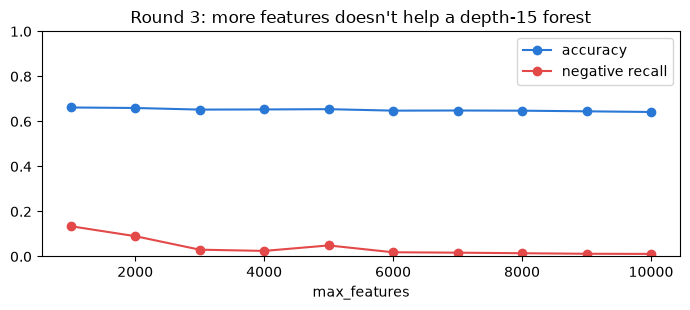

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
xs = range(1000, 10001, 1000)
ax.plot(xs, t3["accuracy"], marker="o", label="accuracy", color="#2a78d6")
ax.plot(xs, t3["negative_recall"], marker="o", label="negative recall", color="#e34948")
ax.set_xlabel("max_features"); ax.set_ylim(0, 1); ax.legend(); ax.set_title("Round 3: more features doesn't help a depth-15 forest")
plt.tight_layout(); plt.show()

With the forest capped at depth 15, extra features mostly add noise. The smallest setting (**1000**) is as good as or better than the rest,
and it gives a smaller, faster model. The course picks **TF-IDF, trigrams, 1000 features** from here on.

## Round 4 · Handling the class imbalance  (5 runs)
| Technique | What it does |
|---|---|
| `class_weight="balanced"` | errors on rare classes cost more; the data is unchanged |
| SMOTE (oversampling) | creates synthetic minority samples by interpolating between neighbours |
| ADASYN | like SMOTE, but creates more samples where the minority class is hard to learn |
| random undersampling | drops majority-class rows until the classes are equal |
| SMOTEENN | SMOTE, then removes noisy rows with Edited Nearest Neighbours |

Resampling is applied to the **training split only**. The test set must keep the real class distribution.

In [8]:
vec = TfidfVectorizer(ngram_range=(1, 3), max_features=1000)
Xtr, Xte = vec.fit_transform(X_train_txt), vec.transform(X_test_txt)
BASE = {"vectorizer": "tfidf", "ngram_range": "(1,3)", "max_features": 1000}

m = RandomForestClassifier(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42, class_weight="balanced")
log_and_score("exp4-imbalance", "class_weight", m, Xtr, y_train, Xte, {**BASE, "imbalance": "class_weight"})

for name, sampler in [("oversampling_smote", SMOTE(random_state=42)),
                      ("adasyn", ADASYN(random_state=42)),
                      ("undersampling", RandomUnderSampler(random_state=42)),
                      ("smote_enn", SMOTEENN(random_state=42))]:
    Xr, yr = sampler.fit_resample(Xtr, y_train)
    counts = pd.Series(yr).value_counts().to_dict()
    log_and_score("exp4-imbalance", name, rf(), Xr, yr, Xte, {**BASE, "imbalance": name, "train_rows": len(yr)})
    print("   resampled class counts:", counts)
table("exp4-imbalance")

2026/09/17 00:43:17 INFO mlflow.tracking.fluent: Experiment with name 'exp4-imbalance' does not exist. Creating a new experiment.


🏃 View run class_weight at: http://127.0.0.1:5050/#/experiments/4/runs/7e6e180f7a1a4282b926e7a66afac002
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/4
class_weight                     acc=0.677  neg_recall=0.464  macro_f1=0.650  (1s)


🏃 View run oversampling_smote at: http://127.0.0.1:5050/#/experiments/4/runs/c61753b671e142ff87009b9fa9f70741
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/4
oversampling_smote               acc=0.671  neg_recall=0.465  macro_f1=0.645  (1s)
   resampled class counts: {-1: 12616, 1: 12616, 0: 12616}


🏃 View run adasyn at: http://127.0.0.1:5050/#/experiments/4/runs/5df1052569b74cacb3c9ea363ac0c8bc
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/4
adasyn                           acc=0.679  neg_recall=0.429  macro_f1=0.648  (1s)
   resampled class counts: {1: 12616, 0: 12507, -1: 12283}


🏃 View run undersampling at: http://127.0.0.1:5050/#/experiments/4/runs/cffe26339b03402d86f17037e1f52101
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/4
undersampling                    acc=0.673  neg_recall=0.474  macro_f1=0.648  (0s)
   resampled class counts: {-1: 6598, 0: 6598, 1: 6598}


🏃 View run smote_enn at: http://127.0.0.1:5050/#/experiments/4/runs/395e2f2ae0224a458b3851b2f0a3ff9d
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/4
smote_enn                        acc=0.449  neg_recall=0.729  macro_f1=0.375  (0s)
   resampled class counts: {-1: 8608, 0: 7489, 1: 1144}


,accuracy,negative_recall,negative_precision,neutral_recall,positive_recall,macro_f1
run,,,,,,
class_weight,0.6765,0.4642,0.6041,0.9257,0.5878,0.6500
oversampling_smote,0.6713,0.4648,0.5877,0.9138,0.5850,0.6451
adasyn,0.6788,0.4291,0.6238,0.9340,0.6049,0.6479
undersampling,0.6730,0.4739,0.6015,0.9280,0.5726,0.6479
smote_enn,0.4487,0.7291,0.3375,0.8248,0.0003,0.3749


Every technique multiplies negative recall several times over round 3 (0.13 → about 0.45).
* **SMOTEENN** has the highest negative recall, as in the video, but here it **collapses**: its cleaning step removes so many rows that the model never predicts *positive* (positive recall 0, accuracy about 0.45).
* The other four are **within about one point** of each other in our run, so there is no clear winner.

The course picks **SMOTE oversampling**, which keeps every original row (undersampling throws data away).
`class_weight="balanced"` is just as good here and simpler: no synthetic rows at all.

## Round 5 · Which algorithm? (Optuna tuning, TF-IDF(1,3) 1000 + SMOTE)
In the video each algorithm gets its own notebook and 30 Optuna trials. Here each gets a small, fixed number of trials so the notebook finishes in minutes.
Optuna scores each trial on a **validation split** (20% of train); only the best configuration is scored once on the test set and logged.

In [9]:
Xs, ys = SMOTE(random_state=42).fit_resample(Xtr, y_train)
Xfit, Xval, yfit, yval = train_test_split(Xs, ys, test_size=0.2, stratify=ys, random_state=42)
# note: validation rows here include synthetic SMOTE rows. Stricter setups resample inside each CV fold.
ENC = {-1: 0, 0: 1, 1: 2}; DEC = {v: k for k, v in ENC.items()}    # XGBoost needs labels 0..n-1

class XGBWrapped(XGBClassifier):                                   # map −1/0/1 ⇄ 0/1/2 transparently
    def fit(self, X, y, **kw): return super().fit(X, pd.Series(y).map(ENC), **kw)
    def predict(self, X): return pd.Series(super().predict(X)).map(DEC).to_numpy()

SPACES = {
    "LogisticRegression": (8, lambda t: LogisticRegression(C=t.suggest_float("C", 1e-3, 10, log=True), max_iter=2000)),
    "LinearSVC":          (8, lambda t: LinearSVC(C=t.suggest_float("C", 1e-3, 10, log=True))),
    "MultinomialNB":      (8, lambda t: MultinomialNB(alpha=t.suggest_float("alpha", 1e-3, 5, log=True))),
    "KNN":                (6, lambda t: KNeighborsClassifier(n_neighbors=t.suggest_int("n_neighbors", 3, 30),
                                                             p=t.suggest_categorical("p", [1, 2]), n_jobs=-1)),
    "RandomForest":       (6, lambda t: RandomForestClassifier(n_estimators=t.suggest_int("n_estimators", 100, 300),
                                                               max_depth=t.suggest_int("max_depth", 10, 40),
                                                               min_samples_split=t.suggest_int("min_samples_split", 2, 10),
                                                               n_jobs=-1, random_state=42)),
    "XGBoost":            (6, lambda t: XGBWrapped(n_estimators=t.suggest_int("n_estimators", 100, 300),
                                                   learning_rate=t.suggest_float("learning_rate", 0.03, 0.3, log=True),
                                                   max_depth=t.suggest_int("max_depth", 3, 10),
                                                   n_jobs=-1, random_state=42, verbosity=0)),
    "LightGBM":           (8, lambda t: LGBMClassifier(n_estimators=t.suggest_int("n_estimators", 100, 400),
                                                       learning_rate=t.suggest_float("learning_rate", 0.03, 0.3, log=True),
                                                       max_depth=t.suggest_int("max_depth", 5, 25),
                                                       num_leaves=t.suggest_int("num_leaves", 20, 80),
                                                       n_jobs=-1, random_state=42, verbose=-1)),
}

BEST = {}
for name, (n_trials, build) in SPACES.items():
    def objective(trial):
        model = build(trial)
        model.fit(Xfit, yfit)
        pred = model.predict(Xval)
        return classification_report(yval, pred, output_dict=True, zero_division=0)["-1"]["recall"] * 0.5 + \
               accuracy_score(yval, pred) * 0.5                     # balance negative recall and accuracy
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    best_model = build(optuna.trial.FixedTrial(study.best_params))
    BEST[name] = study.best_params
    log_and_score("exp5-algorithms-optuna", name, best_model, Xs, ys, Xte,
                  {**BASE, "imbalance": "smote", "algorithm": name, "optuna_trials": n_trials,
                   **{f"best_{k}": v for k, v in study.best_params.items()}})
t5 = table("exp5-algorithms-optuna").sort_values("accuracy", ascending=False); t5

2026/09/17 00:43:54 INFO mlflow.tracking.fluent: Experiment with name 'exp5-algorithms-optuna' does not exist. Creating a new experiment.


🏃 View run LogisticRegression at: http://127.0.0.1:5050/#/experiments/5/runs/36377de79e44415caf851fabd87eb8d5
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/5
LogisticRegression               acc=0.776  neg_recall=0.629  macro_f1=0.756  (0s)


🏃 View run LinearSVC at: http://127.0.0.1:5050/#/experiments/5/runs/5bfabc668f24445bb7fb0599ed6af83d
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/5
LinearSVC                        acc=0.787  neg_recall=0.623  macro_f1=0.768  (0s)
🏃 View run MultinomialNB at: http://127.0.0.1:5050/#/experiments/5/runs/034b776cf18141358bf93ea8273697a4
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/5
MultinomialNB                    acc=0.660  neg_recall=0.657  macro_f1=0.644  (0s)


🏃 View run KNN at: http://127.0.0.1:5050/#/experiments/5/runs/6ba4ac38dd74423fbb8e3ba50998d404
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/5
KNN                              acc=0.477  neg_recall=0.800  macro_f1=0.448  (4s)


🏃 View run RandomForest at: http://127.0.0.1:5050/#/experiments/5/runs/29399568d42b49aa916fd4187c217afd
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/5
RandomForest                     acc=0.722  neg_recall=0.507  macro_f1=0.697  (1s)


🏃 View run XGBoost at: http://127.0.0.1:5050/#/experiments/5/runs/b4daea162a9b4dc7b787aa8f7b5b1015
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/5
XGBoost                          acc=0.788  neg_recall=0.616  macro_f1=0.768  (24s)


🏃 View run LightGBM at: http://127.0.0.1:5050/#/experiments/5/runs/28f57b4f734c476199fd9a1855cdfa22
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/5
LightGBM                         acc=0.779  neg_recall=0.604  macro_f1=0.759  (6s)


,accuracy,negative_recall,negative_precision,neutral_recall,positive_recall,macro_f1
run,,,,,,
XGBoost,0.7875,0.6164,0.7187,0.9458,0.7502,0.7682
LinearSVC,0.7870,0.6230,0.7022,0.9209,0.7654,0.7676
LightGBM,0.7788,0.6036,0.6917,0.9098,0.7654,0.7585
LogisticRegression,0.7758,0.6291,0.6545,0.8932,0.7584,0.7564
RandomForest,0.7215,0.5067,0.6830,0.9371,0.6611,0.6971
MultinomialNB,0.6599,0.6570,0.4557,0.5726,0.7315,0.6441
KNN,0.4769,0.8000,0.3202,0.7129,0.1186,0.4478


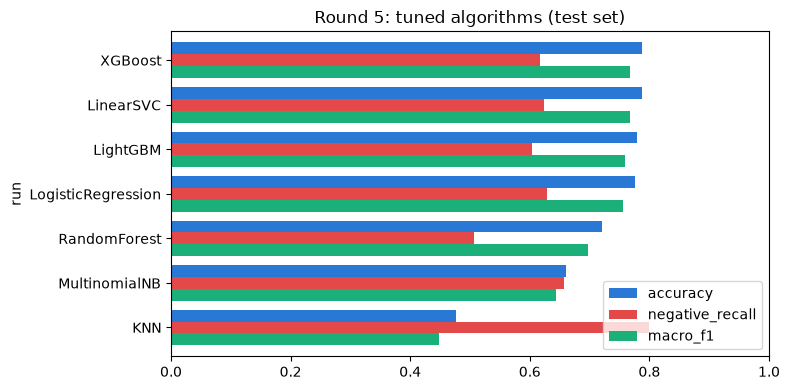

{
 "LogisticRegression": {
  "C": 6.3512210106407005
 },
 "LinearSVC": {
  "C": 6.3512210106407005
 },
 "MultinomialNB": {
  "alpha": 0.003776663327107336
 },
 "KNN": {
  "n_neighbors": 8,
  "p": 2
 },
 "RandomForest": {
  "n_estimators": 175,
  "max_depth": 39,
  "min_samples_split": 8
 },
 "XGBoost": {
  "n_estimators": 175,
  "learning_rate": 0.26781540913060875,
  "max_depth": 8
 },
 "LightGBM": {
  "n_estimators": 212,
  "learning_rate": 0.26781540913060875,
  "max_depth": 20,
  "num_leaves": 56
 }
}


In [10]:
ax = t5[["accuracy", "negative_recall", "macro_f1"]].plot.barh(figsize=(8, 4), color=["#2a78d6", "#e34948", "#1baf7a"], width=.8)
ax.set_xlim(0, 1); ax.invert_yaxis(); ax.set_title("Round 5: tuned algorithms (test set)"); plt.tight_layout(); plt.show()
print(json.dumps(BEST, indent=1))

In our run, **XGBoost and a tuned linear SVM tie for first place** (≈0.787). LightGBM (only 8 quick trials) follows closely and trains about 4× faster than XGBoost.
Tuned linear models are strong, cheap baselines for TF-IDF text. KNN does badly on 1000-dimensional sparse vectors, and naive Bayes lags behind.
The course picks **LightGBM** after a much longer search.
The course then tuned LightGBM on its own (100 Optuna trials). That produced the values in `params.yaml`:
`learning_rate=0.09, max_depth=20, n_estimators=367`.

## Round 6 · LightGBM with the course's parameters, then stacking

In [11]:
final_lgbm = LGBMClassifier(objective="multiclass", num_class=3, learning_rate=0.09, max_depth=20, n_estimators=367,
                            n_jobs=-1, random_state=42, verbose=-1)
log_and_score("exp6-final-vs-stacking", "lightgbm-params-yaml", final_lgbm, Xs, ys, Xte,
              {**BASE, "imbalance": "smote", "algorithm": "LightGBM", "learning_rate": 0.09, "max_depth": 20, "n_estimators": 367})

stack = StackingClassifier(
    estimators=[("lr", LogisticRegression(C=1.0, max_iter=2000)),
                ("knn", KNeighborsClassifier(n_neighbors=10, n_jobs=-1)),
                ("lgbm", LGBMClassifier(learning_rate=0.09, max_depth=20, n_estimators=367, n_jobs=-1, random_state=42, verbose=-1))],
    final_estimator=LogisticRegression(max_iter=2000), cv=3, n_jobs=1)
log_and_score("exp6-final-vs-stacking", "stacking-lr-knn-lgbm", stack, Xs, ys, Xte,
              {**BASE, "imbalance": "smote", "algorithm": "Stacking(LR,KNN,LGBM)+LR", "cv": 3})
table("exp6-final-vs-stacking")

2026/09/17 00:47:46 INFO mlflow.tracking.fluent: Experiment with name 'exp6-final-vs-stacking' does not exist. Creating a new experiment.


🏃 View run lightgbm-params-yaml at: http://127.0.0.1:5050/#/experiments/6/runs/2c3bc972d62648f2972159703f9d7ab5
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/6
lightgbm-params-yaml             acc=0.788  neg_recall=0.605  macro_f1=0.768  (9s)


🏃 View run stacking-lr-knn-lgbm at: http://127.0.0.1:5050/#/experiments/6/runs/59893c4dca764b73bfd342da3dce6005
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/6
stacking-lr-knn-lgbm             acc=0.788  neg_recall=0.635  macro_f1=0.769  (52s)


,accuracy,negative_recall,negative_precision,neutral_recall,positive_recall,macro_f1
run,,,,,,
lightgbm-params-yaml,0.7884,0.6055,0.7141,0.9348,0.7666,0.7676
stacking-lr-knn-lgbm,0.7877,0.6345,0.6821,0.9154,0.7654,0.7687


Stacking lands at about the same score as LightGBM alone, but it trains several models, runs slower at prediction time and is harder to maintain.
**Decision: ship LightGBM.** That's the model the DVC pipeline trains (`pipeline_walkthrough.ipynb`).

## Summary of all rounds

In [12]:
summary = pd.DataFrame(RESULTS)
best_per_round = summary.loc[summary.groupby("experiment")["accuracy"].idxmax(), ["experiment", "run", "accuracy", "negative_recall", "macro_f1"]]
print(best_per_round.to_string(index=False))
json.dump({"runs": RESULTS, "best_params_round5": BEST}, open("../reports/experiment_summary.json", "w"), indent=1, default=str)
print("\nruns logged:", len(RESULTS), "→ open", TRACKING_URI)

             experiment                  run  accuracy  negative_recall  macro_f1
          exp1-baseline           rf-bow-10k    0.6431           0.0042    0.4864
      exp2-bow-vs-tfidf         tfidf-(1, 3)    0.6543           0.0491    0.5183
exp3-tfidf-max-features   tfidf-trigram-1000    0.6618           0.1345    0.5618
         exp4-imbalance               adasyn    0.6788           0.4291    0.6479
 exp5-algorithms-optuna              XGBoost    0.7875           0.6164    0.7682
 exp6-final-vs-stacking lightgbm-params-yaml    0.7884           0.6055    0.7676

runs logged: 31 → open http://127.0.0.1:5050


Open the MLflow UI (`http://127.0.0.1:5050`), select all runs in one experiment, and click **Compare**
to see the parallel-coordinates and scatter plots shown in the video.
The server keeps running for the pipeline notebook. To stop it: `stop_mlflow_server()`.